In [2]:
import pandas as pd

In [3]:
# dpto_CNE_IGN_ref = pd.read_csv('./info/dpto_CNE_IGN_ref.csv', dtype={'codprov': str, 'coddepto': str})


In [7]:
ref_BD = pd.read_csv('./../datos/BD/seccion_table.csv', dtype={'distrito_id': str, 'seccion_id': str})
ref_BD['distrito_id'] = ref_BD['distrito_id'].apply(lambda x: x.zfill(2))
ref_BD['seccion_id'] = ref_BD['seccion_id'].apply(lambda x: x.zfill(3))
ref_BD.head()

,distrito_id,seccion_id,seccionprovincial_id,seccion_nombre
0,01,015,0.0,Comuna 15
1,01,001,0.0,Comuna 01
2,01,004,0.0,Comuna 04
3,04,001,0.0,Capital
4,04,026,0.0,Unión


In [3]:
ref_censo_IGN = pd.read_csv('./../../CNE-INDEC-georef/info/dpto_CNE_IGN_ref.csv', dtype={'codprov': str, 'coddepto': str, 'IN1': str})
ref_censo_IGN.head()

,codprov,coddepto,IN1,NAM,counts
0,01,001,02007,Comuna 1,19
1,01,002,02014,Comuna 2,10
2,01,003,02021,Comuna 3,13
3,01,004,02028,Comuna 4,15
4,01,005,02035,Comuna 5,10


In [9]:
## Esto se revisa a mano, da lugar a las diferencias en san juan y misiones. 

# merge = ref_BD.merge(ref_censo_IGN, left_on = ['distrito_id', 'seccion_id'], right_on = ['codprov', 'coddepto'], how = 'outer', indicator=True)
# merge.sort_values(['distrito_id', '_merge', 'seccion_nombre']).to_csv('./disambiguar.csv')

# merge.loc[merge._merge != 'both']

# deberia ser 4 25
# 4	0	14175	Tulumba


In [90]:
claves_dptos = pd.read_csv('./../datos/BD/claves_dptos_ref.csv')
claves_dptos = claves_dptos.loc[~claves_dptos.codprov.isna()].astype({'codprov': 'Int64', 'coddepto' : 'Int64', 'IN1' : 'Int64'})
claves_dptos['codprov'] = claves_dptos['codprov'].astype(str).str.zfill(2)
claves_dptos['coddepto'] = claves_dptos['coddepto'].astype(str).str.zfill(3)
claves_dptos['IN1'] = claves_dptos['IN1'].astype(str).str.zfill(5)
claves_dptos.head()

,distrito_id,seccion_id,seccionprovincial_id,seccion_nombre,codprov,coddepto,IN1,NAM
0,1,1,0,Comuna 01,01,001,02007,Comuna 1
1,1,2,0,Comuna 02,01,002,02014,Comuna 2
2,1,3,0,Comuna 03,01,003,02021,Comuna 3
3,1,4,0,Comuna 04,01,004,02028,Comuna 4
4,1,5,0,Comuna 05,01,005,02035,Comuna 5


In [7]:
circuito_table = pd.read_csv('./../datos/BD/circuito_table.csv')[['distrito_id', 'seccion_id', 'circuito_id']].drop_duplicates().reset_index(drop=True)

# circuito_table.tail()

# 	distrito_id	seccion_id	circuito_id
# 6756	24	1	000U14
# 6757	24	1	000U12
# 6758	24	1	000U13
# 6759	24	1	000U11
# 6760	15	9	000960

,eleccion_id,distrito_id,seccion_id,seccionprovincial_id,circuito_id,circuito_nombre
0,1,1,15,0.0,000161,NaN
1,1,1,15,0.0,000159,NaN
2,1,1,15,0.0,000162,NaN
3,1,1,15,0.0,000163,NaN
4,1,1,1,0.0,000002,NaN
...,...,...,...,...,...,...
100083,11,23,14,14.0,000202,NaN
100084,11,23,14,14.0,000203,NaN
100085,11,23,14,14.0,000204,NaN
100086,11,23,14,14.0,000205,NaN


In [35]:
circuito_table.shape

(6171, 3)

In [92]:
# circ_dpto_CNE_IGN = pd.read_csv('./../../CNE-INDEC-georef/info/circ_dpto_CNE_IGN.csv')
circ_dpto_CNE_IGN = gpd.read_file('./../../CNE-INDEC-georef/info/circ_dpto_IGN.geojson')
circ_dpto_CNE_IGN['circuito'] = circ_dpto_CNE_IGN['circuito'].str.zfill(6)
circ_CNE = circ_dpto_CNE_IGN.merge(claves_dptos, how = 'left')

In [93]:
circ_BD = circuito_table


In [94]:
merged = circ_BD.merge(circ_CNE, left_on=['distrito_id', 'seccion_id', 'circuito_id'], right_on = ['distrito_id', 'seccion_id', 'circuito'], how = 'outer', indicator = True)
merged

,distrito_id,seccion_id,circuito_id,codprov,coddepto,circuito,IN1,NAM,geometry,seccionprovincial_id,seccion_nombre,_merge
0,1.0,15.0,000161,01,015,000161,02105,Comuna 15,"POLYGON Z ((-58.43720 -34.60460 0.00000, -58.4...",0.0,Comuna 15,both
1,1.0,15.0,000159,01,015,000159,02105,Comuna 15,"POLYGON Z ((-58.44220 -34.59670 0.00000, -58.4...",0.0,Comuna 15,both
2,1.0,15.0,000162,01,015,000162,02105,Comuna 15,"POLYGON Z ((-58.46920 -34.58870 0.00000, -58.4...",0.0,Comuna 15,both
3,1.0,15.0,000163,01,015,000163,02105,Comuna 15,"POLYGON Z ((-58.43860 -34.58870 0.00000, -58.4...",0.0,Comuna 15,both
4,1.0,1.0,000002,01,001,000002,02007,Comuna 1,"POLYGON Z ((-58.37740 -34.61630 0.00000, -58.3...",0.0,Comuna 01,both
...,...,...,...,...,...,...,...,...,...,...,...,...
6220,NaN,NaN,NaN,24,02,000014,94007,Río Grande,"MULTIPOLYGON Z (((-67.63620 -53.80993 0.00000,...",NaN,NaN,right_only
6221,NaN,NaN,NaN,24,02,000016,94007,Río Grande,"POLYGON Z ((-68.30958 -53.32111 0.00000, -68.3...",NaN,NaN,right_only
6222,NaN,NaN,NaN,24,02,000021,94011,Tolhuin,"POLYGON Z ((-67.24502 -54.48237 0.00000, -67.1...",NaN,NaN,right_only
6223,NaN,NaN,NaN,24,02,000210,94007,Río Grande,"POLYGON Z ((-67.73932 -53.77926 0.00000, -67.7...",NaN,NaN,right_only


In [95]:
merged._merge.value_counts()

_merge
both          5449
left_only      722
right_only      54
Name: count, dtype: int64

In [96]:
merged.loc[merged._merge != 'both'].nunique()

distrito_id              22
seccion_id               43
circuito_id             486
codprov                  12
coddepto                 21
circuito                 47
IN1                      32
NAM                      32
geometry                 54
seccionprovincial_id      1
seccion_nombre           10
_merge                    2
dtype: int64

In [97]:
merged_right = merged.loc[merged._merge != 'left_only']
merged_right.count()

distrito_id             5460
seccion_id              5460
circuito_id             5449
codprov                 5503
coddepto                5503
circuito                5503
IN1                     5503
NAM                     5503
geometry                5503
seccionprovincial_id    5460
seccion_nombre          5460
_merge                  5503
dtype: int64

In [101]:
circs_ref = gpd.GeoDataFrame(merged_right.drop('_merge', axis = 1))
circs_ref.to_file('./../datos/geojson/circs_ref.geojson', driver='GeoJSON')

<Axes: >

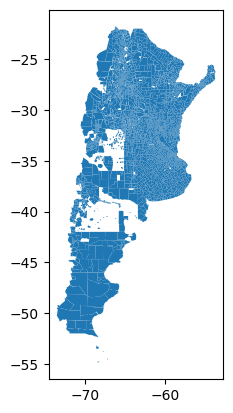

In [102]:
circs_ref.plot()

In [65]:
# pd.options.display.max_rows = 400

In [67]:
# merged.loc[merged._merge != 'both'].drop('_merge', axis = 1).fillna('-').groupby(['distrito_id', 'seccion_id', 'IN1', 'NAM']).circuito.unique()

In [72]:
import geopandas as gpd
circs_dpto_IGN = gpd.read_file('./../../CNE-INDEC-georef/info/circ_dpto_IGN.geojson')
circs_dpto_IGN['circuito'] = circs_dpto_IGN['circuito'].str.zfill(6)


In [73]:
circs_dpto_IGN.head()

,codprov,coddepto,circuito,IN1,NAM,geometry
0,01,001,00001,02007,Comuna 1,"POLYGON Z ((-58.36610 -34.62150 0.00000, -58.3..."
1,01,001,00002,02007,Comuna 1,"POLYGON Z ((-58.37740 -34.61630 0.00000, -58.3..."
2,01,001,00003,02007,Comuna 1,"POLYGON Z ((-58.35720 -34.59510 0.00000, -58.3..."
3,01,001,00004,02007,Comuna 1,"POLYGON Z ((-58.36770 -34.60740 0.00000, -58.3..."
4,01,001,00005,02007,Comuna 1,"POLYGON Z ((-58.37984 -34.58016 0.00000, -58.3..."


In [76]:
circs_dpto_IGN[['codprov', 'coddepto', 'circuito']].drop_duplicates().shape

(5503, 3)

In [77]:
circs_dpto_IGN[['IN1', 'circuito']].drop_duplicates().shape

(5503, 2)